# Flight Delay Analysis Predictive Model

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import os
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Libraries Imported Successfully!")


Libraries Imported Successfully!


## Load Datasets

In [2]:
# Import Csv File
df = pd.read_csv("Airline_Delay_Cause.csv")

# Basic info
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"\nColumn Names:\n{list(df.columns)}")
print(f"\nDate Range: {df['year'].min()} - {df['year'].max()}")
print(f"Total Airlines: {df['carrier_name'].nunique()}")
print(f"Total Airports: {df['airport'].nunique()}")

Rows: 171,666  |  Columns: 21

Column Names:
['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name', 'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']

Date Range: 2013 - 2023
Total Airlines: 23
Total Airports: 395


## Checking Data Quality

In [3]:
# Check Missing Values
print("--- Missing Values ---")
print(df.isnull().sum())

# Check Duplicate Values
print("\n--- Duplicate Rows ---")
print(f" Duplicates: {df.duplicated().sum()}")

# Data Types
print(f"\n--- Data Types---")
print(df.dtypes) 

print(f"\n--- Basic Stats ---")
print(df[['arr_flights','arr_del15','arr_delay',
          'carrier_delay','weather_delay',
          'nas_delay','late_aircraft_delay']].describe().round(2))

--- Missing Values ---
year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            240
arr_del15              443
carrier_ct             240
weather_ct             240
nas_ct                 240
security_ct            240
late_aircraft_ct       240
arr_cancelled          240
arr_diverted           240
arr_delay              240
carrier_delay          240
weather_delay          240
nas_delay              240
security_delay         240
late_aircraft_delay    240
dtype: int64

--- Duplicate Rows ---
 Duplicates: 0

--- Data Types---
year                     int64
month                    int64
carrier                    str
carrier_name               str
airport                    str
airport_name               str
arr_flights            float64
arr_del15              float64
carrier_ct             float64
weather_ct             float64
nas_ct                 float6

## Data Cleaning

In [4]:
# Drop rows where arr_flights missing
df_clean = df.dropna(subset=['arr_flights']).copy()
print(f"Rows before cleaning: {len(df):,}")
print(f"Rows after cleaning: {len(df_clean):,}")
print(f"Rows dropped: {len(df) - len(df_clean):,}")

# Fill remaining missing values with 0
delay_colmns = ['carrier_delay', 'weather_delay', 'nas_delay', 
              'security_delay', 'late_aircraft_delay', 'arr_del15']
df_clean[delay_colmns] = df_clean[delay_colmns].fillna(0)

# Delay rate column, flight delay percentage
df_clean['delay_rate'] = df_clean['arr_del15'] / df_clean['arr_flights'] * 100

# Targeted column for ML Model
df_clean['delay_label'] = (df_clean['delay_rate'] > 20).astype(int) #if delay_rate > 20% then High else Low

print(f"\nDelay Label Distribution")
print(df_clean['delay_label'].value_counts())
print(f"\n High Delay Routes {df_clean['delay_label'].mean()*100:.1f}%")

Rows before cleaning: 171,666
Rows after cleaning: 171,426
Rows dropped: 240

Delay Label Distribution
delay_label
0    106383
1     65043
Name: count, dtype: int64

 High Delay Routes 37.9%


## EDA: Top 10 Airlines by delay rate

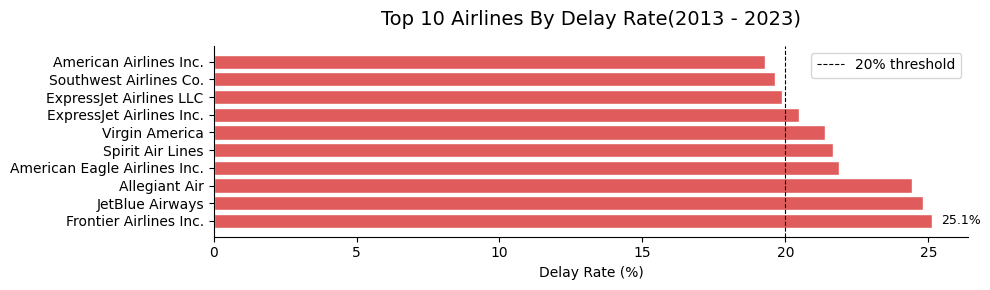

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

In [5]:
#Top 10 Highest Delay Airlines
airline_delay = df_clean.groupby('carrier_name').agg(
    total_flights = ('arr_flights', 'sum'),
    total_delay = ('arr_del15', 'sum')
).reset_index()

airline_delay['delay_rate'] = airline_delay['total_delay'] / airline_delay['total_flights'] * 100
airline_delay = airline_delay.sort_values('delay_rate', ascending=False).head(10)

#Horizontal Bar Chart

fig, ax = plt.subplots(figsize=(10,3))
bars = ax.barh(airline_delay['carrier_name'], airline_delay['delay_rate'],
               color='#e05c5c', edgecolor='white')

for bar, val in zip(bars, airline_delay['delay_rate']):
    ax.text(bar.get_width()+ 0.3 , bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
    ax.set_title("Top 10 Airlines By Delay Rate(2013 - 2023)", fontsize = 14, pad = 15)
    ax.set_xlabel('Delay Rate (%)')
    ax.axvline(20, color='black', linestyle = '--', linewidth= 0.8, label = '20% threshold' )
    ax.legend()
    plt.tight_layout()
    plt.show()
    plt.close('all')

## Delay Causes Breakdown

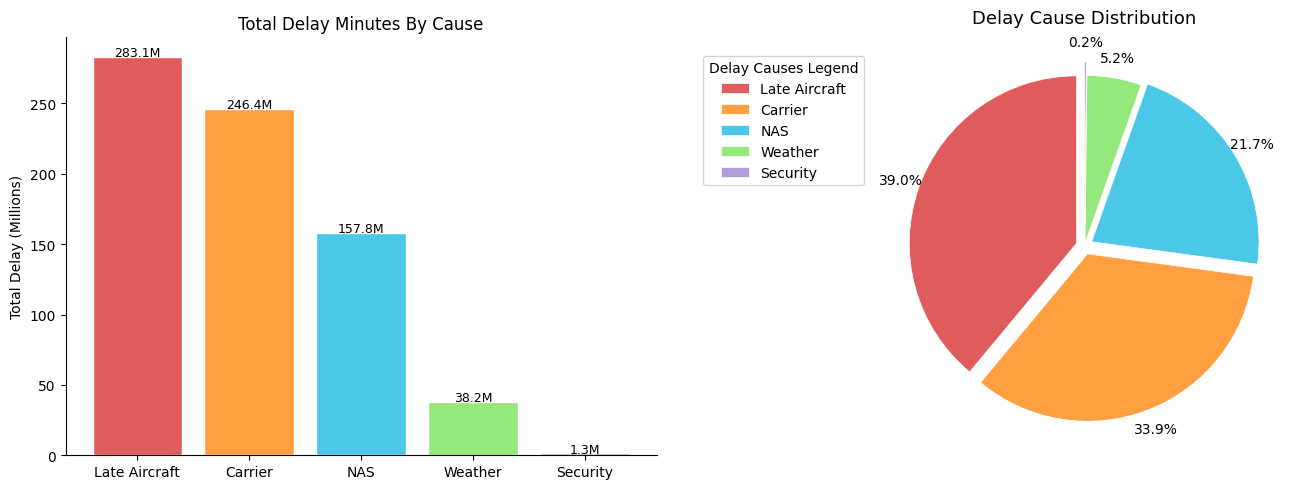

In [6]:
delay_causes = {
     'Carrier': df_clean['carrier_delay'].sum(),
    'Weather': df_clean['weather_delay'].sum(),
    'NAS': df_clean['nas_delay'].sum(),
    'Security': df_clean['security_delay'].sum(),
    'Late Aircraft': df_clean['late_aircraft_delay'].sum()
}
causes_df = pd.Series(delay_causes).sort_values(ascending=False)
total = causes_df.sum()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5))

# Bar Chart
colors = ['#e05c5c', '#ff9f40', '#4bc8e8', '#95e87b', '#b19cd9']
bars = ax1.bar(causes_df.index, causes_df.values / 1e6,
               color=colors, edgecolor='white')

for bar , val in zip(bars, causes_df.values) :
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val/1e6:.1f}M', ha='center', fontsize=9)
    ax1.set_title('Total Delay Minutes By Cause', fontsize=12)
    ax1.set_ylabel('Total Delay (Millions)')

# Pie Chart
ax2.pie(causes_df.values, labels=None,
        autopct='%1.1f%%', colors=colors, startangle=90,
        pctdistance=1.12,
        explode=(0.05, 0.05, 0.05, 0.02, 0.1),
        wedgeprops={'edgecolor': 'white', 'linewidth': 0.5})

ax2.set_title('Delay Cause Distribution', fontsize=13, pad=10)
ax2.legend(labels=causes_df.index, 
          title="Delay Causes Legend", 
          loc="center right", 
          bbox_to_anchor=(-0.01, 0.8))
plt.tight_layout()
plt.show()
plt.close('all')


## Yearly Delay Trend

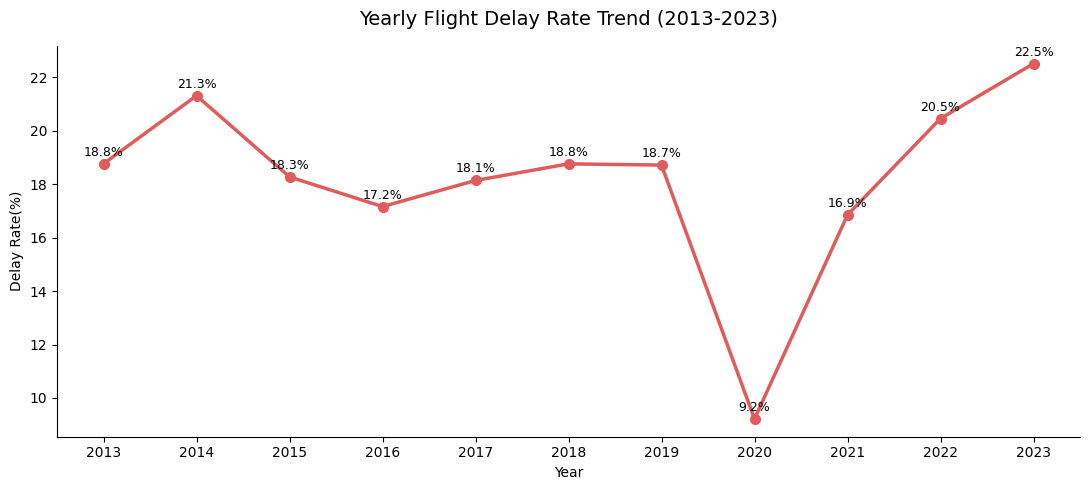

In [11]:
yearly_delay = df_clean.groupby('year').agg(
    total_flights=('arr_flights', 'sum'),
    total_delayed=('arr_del15','sum')
).reset_index()

yearly_delay['delay_rate'] = yearly_delay['total_delayed'] / yearly_delay['total_flights'] * 100

fig,ax = plt.subplots(figsize=(11,5))
ax.plot(yearly_delay['year'], yearly_delay['delay_rate'],
        color = '#e05c5c', linewidth=2.5,marker='o', markersize=7)

for x,y in zip(yearly_delay['year'], yearly_delay['delay_rate']):
    ax.text(x, y+0.3,f'{y:.1f}%',ha='center',fontsize=9)

ax.set_title('Yearly Flight Delay Rate Trend (2013-2023)', fontsize = 14, pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Delay Rate(%)')
ax.set_xticks(yearly_delay['year'])
plt.tight_layout()
plt.show()
plt.close('all')

## Monthly Seasonality

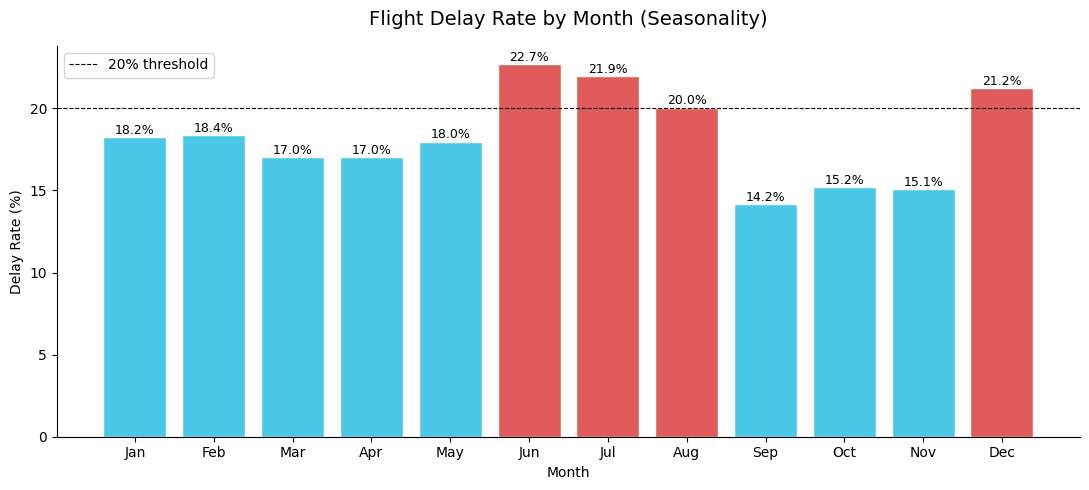

In [13]:
# Most Delayed Month
monthly = df_clean.groupby('month').agg(
    total_flights=('arr_flights', 'sum'),
    total_delayed=('arr_del15', 'sum')
).reset_index()

monthly['delay_rate'] = monthly['total_delayed'] / monthly['total_flights'] * 100
monthly['month_name'] = pd.to_datetime(monthly['month'], format='%m').dt.strftime('%b')

fig, ax = plt.subplots(figsize=(11, 5))
colors_monthly = ['#e05c5c' if x > 20 else '#4bc8e8' for x in monthly['delay_rate']]
bars = ax.bar(monthly['month_name'], monthly['delay_rate'], 
              color=colors_monthly, edgecolor='white')

for bar, val in zip(bars, monthly['delay_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', fontsize=9)

ax.axhline(20, color='black', linestyle='--', linewidth=0.8, label='20% threshold')
ax.set_title('Flight Delay Rate by Month (Seasonality)', fontsize=14, pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Delay Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()
plt.close('all')

## Predictive Model

Model Accuracy: 96.21%

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     21200
           1       0.96      0.94      0.95     13086

    accuracy                           0.96     34286
   macro avg       0.96      0.96      0.96     34286
weighted avg       0.96      0.96      0.96     34286



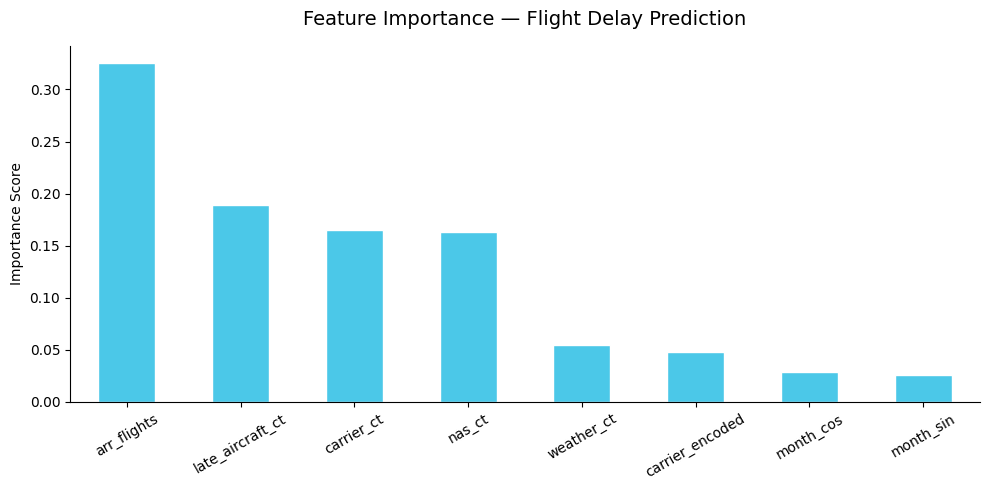

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Features prepare karo
le = LabelEncoder()
df_model = df_clean.copy()
df_model['carrier_encoded'] = le.fit_transform(df_model['carrier'])
df_model['month_sin'] = np.sin(2 * np.pi * df_model['month'] / 12)
df_model['month_cos'] = np.cos(2 * np.pi * df_model['month'] / 12)

# Feature columns
features = ['carrier_encoded', 'month_sin', 'month_cos',
            'carrier_ct', 'weather_ct', 'nas_ct',
            'late_aircraft_ct', 'arr_flights']

X = df_model[features]
y = df_model['delay_label']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Model train
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Results
accuracy = rf.score(X_test, y_test) * 100
print(f"Model Accuracy: {accuracy:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf.predict(X_test)))

# Feature Importance
feat_imp = pd.Series(rf.feature_importances_, 
                     index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.plot(kind='bar', color='#4bc8e8', edgecolor='white', ax=ax)
ax.set_title('Feature Importance — Flight Delay Prediction', fontsize=14, pad=15)
ax.set_ylabel('Importance Score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
plt.close('all')

## Confusion Matrix

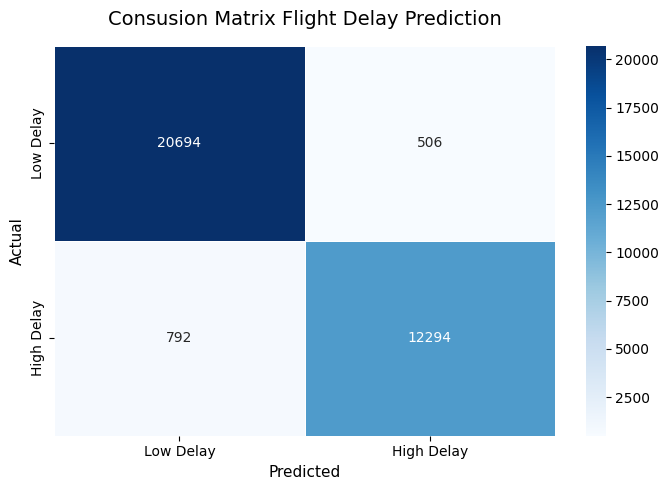

In [18]:
cm = confusion_matrix(y_test, rf.predict(X_test))

fig,ax = plt.subplots(figsize=(7,5))
sns.heatmap(cm,annot=True, fmt='d', cmap='Blues', xticklabels=['Low Delay', 'High Delay'],
            yticklabels=['Low Delay', 'High Delay'], linewidth=0.5, ax=ax)

ax.set_title('Confusion Matrix Flight Delay Prediction', fontsize=14, pad=15)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
plt.tight_layout()
plt.show()
plt.close('all')

## Key Insights

**Insight 1 - Delay Causes:**
Late Aircraft is the #1 delay cause (39%), one delayed flight creates 
a chain reaction across multiple routes. Airlines must prioritize 
on-time departure of first flights of the day.

**Insight 2 - Worst Airlines:**
Frontier Airlines (25.1%) and JetBlue (24.8%) have the highest delay 
rates, both are budget carriers suggesting cost-cutting impacts 
operational efficiency.

**Insight 3 - Seasonality:**
June and July see 22%+ delay rates due to summer travel surge. 
September is the best month to fly (14.2% delay rate).

**Insight 4 - COVID Impact:**
2020 showed only 9.2% delay rate, fewer flights meant better 
on-time performance. Post-COVID 2023 hit 22.5%, highest in decade.

## Recommendations

**1. Focus on Morning Departures:**
Since Late Aircraft is #1 cause, ensuring first flights of the day 
depart on time can reduce chain delays by up to 30-40%.

**2. Seasonal Staffing:**
Airlines should increase ground staff and crew by 20-25% during 
June, July and December to handle peak demand.

**3. Target Budget Carriers:**
Frontier and JetBlue need operational overhaul, stricter turnaround 
time targets and better maintenance scheduling.